# Phần 3 — Sales Forecasting (Final)

**Goal**: Dự báo `Revenue` và `COGS` daily cho giai đoạn 01/01/2023 → 01/07/2024 (548 ngày).

**Constraints (đề bài)**:
- Train: 04/07/2012 → 31/12/2022 (sales.csv) — TẤT CẢ 11 năm rưỡi
- Test: 01/01/2023 → 01/07/2024 (sales_test.csv)
- Không dùng Revenue/COGS từ test làm features (disqualify)
- Không dùng external data
- Reproducible (random seed cố định)
- Explainability (SHAP/feature importance trong report)

**Metrics đánh giá**: MAE, RMSE, R²

**Strategy**:
1. **Two-stage**: Baseline (seasonal × trend) → ML residuals
2. **Features**: time + lag + promotion + web traffic + VN seasonal + mega sales (51 features)
3. **2 models**: XGBoost + CatBoost (đã verify thắng baseline; bỏ LightGBM)
4. **Optuna tuning bằng CV mean MAE** (3 folds: val 2020/2021/2022)
5. **Ensemble blend** trung bình qua 3 folds
6. **Final retrain trên ALL TRAIN** (2012-2022) → predict test
7. **SHAP** trên CatBoost cho explainability

**Cải tiến vs baseline cũ của teammate**:
- Fix bug promotion shift (chỉ shift 2021 → giờ replicate cycle 2 năm 2021→2023, 2022→2024)
- CV multi-fold tuning (thay vì single fold 2022 → tránh overfit)
- Tune bằng MAE (đề bài chấm bằng MAE, không phải MAPE)
- Features từ Mart 4: web_traffic lag, days_to_tet, mega sales flags
- Không dùng sample_submission làm ground truth
- Ensemble blend với CV-averaged weights
- SHAP analysis cho top features

## 1. Setup & Imports

In [1]:
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# Models — chỉ XGBoost + CatBoost (LightGBM bỏ vì đã verify XGB+Cat thắng baseline)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

print('Imports done. Random seed:', SEED)

Imports done. Random seed: 42


In [2]:
# Project paths — chỉnh theo cấu trúc folder của bạn
DATA_DIR      = Path('../data')
RAW_DIR       = DATA_DIR / 'raw'
INTERIM_DIR   = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'

FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

OUT_FILE = DATA_DIR / 'submission_final.csv'

for p in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR]:
    assert p.exists(), f'Missing dir: {p}'

print(f'Data raw:       {RAW_DIR}')
print(f'Data processed: {PROCESSED_DIR}')
print(f'Output:         {OUT_FILE}')

Data raw:       ..\data\raw
Data processed: ..\data\processed
Output:         ..\data\submission_final.csv


## 2. Load Data

- `sales.csv` (raw target — Revenue & COGS daily)
- `sample_submission.csv` (test dates — chỉ dùng cột Date làm skeleton, KHÔNG dùng giá trị)
- `promotions.csv` (raw — fix bug shift)
- `mart4_daily_ops.parquet` (web_traffic, date_dim từ EDA Phần 2)
- `mart5_promotion_perf.parquet` (promo metrics tham khảo)

In [3]:
# Sales train data
sales = pd.read_csv(RAW_DIR / 'sales.csv', parse_dates=['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)

# Test dates — chỉ lấy cột Date (số trong sample_submission là PLACEHOLDER!)
sample_sub = pd.read_csv(RAW_DIR / 'sample_submission.csv', parse_dates=['Date'])
test_dates = sample_sub[['Date']].copy().sort_values('Date').reset_index(drop=True)

print(f'Train: {len(sales):,} rows, {sales["Date"].min().date()} → {sales["Date"].max().date()}')
print(f'Test:  {len(test_dates):,} rows, {test_dates["Date"].min().date()} → {test_dates["Date"].max().date()}')
assert sales['Date'].max() < test_dates['Date'].min(), 'Train/test overlap!'
print('No overlap. OK.')

Train: 3,833 rows, 2012-07-04 → 2022-12-31
Test:  548 rows, 2023-01-01 → 2024-07-01
No overlap. OK.


In [4]:
# Marts từ EDA Phần 2
mart4 = pd.read_parquet(PROCESSED_DIR / 'mart4_daily_ops.parquet')
mart5 = pd.read_parquet(PROCESSED_DIR / 'mart5_promotion_perf.parquet')

print(f'Mart 4: {mart4.shape}, range {mart4["date"].min().date()} → {mart4["date"].max().date()}')
print(f'Mart 5: {mart5.shape}, {mart5["promo_id"].nunique()} unique promos')

# Promotions raw
promotions = pd.read_csv(RAW_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
print(f'\nPromotions: {len(promotions)} rows')
print(f'  Year range: {promotions["start_date"].dt.year.min()} → {promotions["start_date"].dt.year.max()}')

Mart 4: (4381, 54), range 2012-07-04 → 2024-07-01
Mart 5: (50, 21), 50 unique promos

Promotions: 50 rows
  Year range: 2013 → 2022


## 3. Baseline Model (Seasonal × Trend)

**Formula**: `prediction[d] = base_level × (growth_rate ^ years_ahead) × seasonal_factor[d.month, d.day]`

- `base_level`: avg daily revenue/cogs của năm cuối training
- `growth_rate`: geometric mean YoY growth từ 2013 đến năm cuối training
- `seasonal_factor`: avg normalized revenue/cogs theo (month, day) trên toàn lịch sử

In [5]:
def fit_baseline(df_train, upper_year):
    """Fit baseline trên data ≤ upper_year."""
    tr = df_train[df_train['Date'].dt.year <= upper_year].copy()
    tr['year']  = tr['Date'].dt.year
    tr['month'] = tr['Date'].dt.month
    tr['day']   = tr['Date'].dt.day

    # Seasonal profile
    annual_means = tr.groupby('year')[['Revenue', 'COGS']].transform('mean')
    tr['rev_norm']  = tr['Revenue'] / annual_means['Revenue']
    tr['cogs_norm'] = tr['COGS']    / annual_means['COGS']
    seasonal = tr.groupby(['month', 'day'])[['rev_norm', 'cogs_norm']].mean().reset_index()

    # YoY growth (geometric mean)
    annual = tr.groupby('year')[['Revenue', 'COGS']].sum()
    if upper_year not in annual.index:
        upper_year = annual.index.max()

    available_years = annual.index[annual.index <= upper_year]
    if len(available_years) >= 2:
        full_years = annual.loc[available_years]
        n = len(full_years) - 1
        gr_rev  = (1 + full_years['Revenue'].pct_change().dropna()).prod() ** (1 / n)
        gr_cogs = (1 + full_years['COGS'].pct_change().dropna()).prod() ** (1 / n)
    else:
        gr_rev = gr_cogs = 1.0

    base_rev  = annual.loc[upper_year, 'Revenue'] / 365
    base_cogs = annual.loc[upper_year, 'COGS']    / 365

    return {
        'seasonal': seasonal,
        'growth_rev': gr_rev, 'growth_cogs': gr_cogs,
        'base_rev':   base_rev, 'base_cogs':  base_cogs,
        'upper_year': upper_year,
    }


def predict_baseline(dates_df, bp):
    df = dates_df.copy()
    df['year']  = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day']   = df['Date'].dt.day

    df = df.merge(bp['seasonal'], on=['month', 'day'], how='left')
    df['rev_norm']  = df['rev_norm'].fillna(1.0)
    df['cogs_norm'] = df['cogs_norm'].fillna(1.0)
    df['years_ahead'] = df['year'] - bp['upper_year']

    df['Revenue_pred'] = (bp['base_rev']  * (bp['growth_rev']  ** df['years_ahead']) * df['rev_norm'])
    df['COGS_pred']    = (bp['base_cogs'] * (bp['growth_cogs'] ** df['years_ahead']) * df['cogs_norm'])
    return df[['Date', 'Revenue_pred', 'COGS_pred']]


# Sanity check: fit ≤2021, predict 2022
bp_test = fit_baseline(sales, upper_year=2021)
val_22 = sales[sales['Date'].dt.year == 2022].copy()
pred_22 = predict_baseline(val_22[['Date']], bp_test)
val_22 = val_22.merge(pred_22, on='Date')

print('Baseline sanity check (fit ≤2021, predict 2022):')
print(f'  Revenue MAE:  {mean_absolute_error(val_22["Revenue"], val_22["Revenue_pred"]):>12,.0f}')
print(f'  Revenue RMSE: {np.sqrt(mean_squared_error(val_22["Revenue"], val_22["Revenue_pred"])):>12,.0f}')
print(f'  Revenue R²:   {r2_score(val_22["Revenue"], val_22["Revenue_pred"]):.4f}')
print(f'  COGS    MAE:  {mean_absolute_error(val_22["COGS"], val_22["COGS_pred"]):>12,.0f}')
print(f'  COGS    R²:   {r2_score(val_22["COGS"], val_22["COGS_pred"]):.4f}')

Baseline sanity check (fit ≤2021, predict 2022):
  Revenue MAE:       606,502
  Revenue RMSE:      827,865
  Revenue R²:   0.7554
  COGS    MAE:       512,659
  COGS    R²:   0.7670


## 4. Baseline cho từng training year (no leakage)

Với mỗi year Y, fit baseline trên data ≤ Y-1, predict Y.
→ ML model học residuals từ baseline được fit không có data của ngày đó.

In [6]:
# Auto-detect year range để robust với data ngắn
min_year = sales['Date'].dt.year.min()
max_year = sales['Date'].dt.year.max()
years_to_predict = range(min_year + 2, max_year + 1)  # cần ≥ 2 năm history
print(f'Years to compute baseline for: {list(years_to_predict)}')

base_predictions = []
for year in years_to_predict:
    bp = fit_baseline(sales, upper_year=year - 1)
    val = sales[sales['Date'].dt.year == year][['Date']].copy()
    pred = predict_baseline(val, bp)
    base_predictions.append(pred)

base_df = pd.concat(base_predictions, ignore_index=True)
print(f'Baseline computed for {len(base_df):,} dates')

# Merge với sales
train_full = sales.merge(base_df, on='Date', how='inner')
train_full['rev_residual']  = train_full['Revenue'] - train_full['Revenue_pred']
train_full['cogs_residual'] = train_full['COGS']    - train_full['COGS_pred']

print(f'\nTrain full: {len(train_full):,} rows')
print(f'  Years: {sorted(train_full["Date"].dt.year.unique())}')

Years to compute baseline for: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Baseline computed for 3,287 dates

Train full: 3,287 rows
  Years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


## 5. Feature Engineering

5.1. Time features (cyclical)
5.2. Lag features (365, 372 ngày — no leakage)
5.3. Promotion features (FIX bug)
5.4. Web traffic lag (Mart 4)
5.5. Vietnamese seasonality (Mart 4 date_dim)
5.6. Mega sales flags (insight EDA C.1.2)

### 5.1 Time Features

In [7]:
def create_time_features(df, min_date):
    df = df.copy()
    df['year']        = df['Date'].dt.year
    df['month']       = df['Date'].dt.month
    df['day']         = df['Date'].dt.day
    df['dayofweek']   = df['Date'].dt.dayofweek
    df['dayofyear']   = df['Date'].dt.dayofyear
    df['weekofyear']  = df['Date'].dt.isocalendar().week.astype(int)
    df['quarter']     = df['Date'].dt.quarter
    df['is_month_end']    = df['Date'].dt.is_month_end.astype(int)
    df['is_month_start']  = df['Date'].dt.is_month_start.astype(int)
    df['is_quarter_end']  = df['Date'].dt.is_quarter_end.astype(int)
    df['time_idx']        = (df['Date'] - min_date).dt.days

    # Cyclical
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['year_sin_1']  = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['year_cos_1']  = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    df['year_sin_2']  = np.sin(4 * np.pi * df['dayofyear'] / 365.25)
    df['year_cos_2']  = np.cos(4 * np.pi * df['dayofyear'] / 365.25)
    return df


MIN_DATE = sales['Date'].min()  # raw min, KHÔNG sau filter
train_full = create_time_features(train_full, MIN_DATE)
print(f'After time features: {train_full.shape}')
print(f'MIN_DATE: {MIN_DATE.date()}')

After time features: (3287, 26)
MIN_DATE: 2012-07-04


### 5.2 Lag Features (no leakage)

In [8]:
# Lag 365 (cùng ngày năm trước) và 372 (= 365 + 7) cho residuals và actuals
train_full = train_full.sort_values('Date').reset_index(drop=True)

train_full['rev_lag_365']  = train_full['rev_residual'].shift(365)
train_full['rev_lag_372']  = train_full['rev_residual'].shift(372)
train_full['cog_lag_365']  = train_full['cogs_residual'].shift(365)
train_full['cog_lag_372']  = train_full['cogs_residual'].shift(372)

# Monthly mean lags (shift 365 để no leakage)
train_full['ym'] = train_full['Date'].dt.strftime('%Y-%m')
ym_means = train_full.groupby('ym')[['Revenue', 'COGS']].mean().reset_index()
ym_means.columns = ['ym', 'rev_monthly_mean', 'cogs_monthly_mean']
train_full = train_full.merge(ym_means, on='ym', how='left')
train_full['rev_monthly_mean_lag365']  = train_full['rev_monthly_mean'].shift(365)
train_full['cogs_monthly_mean_lag365'] = train_full['cogs_monthly_mean'].shift(365)

print(f'After lag features: {train_full.shape}')
for c in ['rev_lag_365', 'cog_lag_365', 'rev_monthly_mean_lag365']:
    print(f'  NaN {c}: {train_full[c].isna().sum()}')

After lag features: (3287, 35)
  NaN rev_lag_365: 365
  NaN cog_lag_365: 365
  NaN rev_monthly_mean_lag365: 365


### 5.3 Promotion Features — FIX BUG TEAMMATE

Bug cũ: chỉ shift promo của 2021 → 2024 không có promo data.

Fix: với train period dùng promo thực tế. Với test period 2023-2024, replicate cycle 2 năm trước (2021→2023, 2022→2024).

In [9]:
def build_promo_daily(promotions_df, target_date_range):
    """Build daily promo features.

    Logic:
    - Train period (2012-2022): dùng promo thực tế overlap target
    - Test period (2023-2024): replicate promo từ 2 năm trước (2021→2023, 2022→2024)
    """
    target_min = pd.Timestamp(target_date_range.min())
    target_max = pd.Timestamp(target_date_range.max())

    if target_min.year >= 2023:
        # Test: replicate từ 2-year-ago window
        replicate_start = target_min - pd.DateOffset(years=2)
        replicate_end   = target_max - pd.DateOffset(years=2)
        promo_src = promotions_df[
            (promotions_df['start_date'] >= replicate_start) &
            (promotions_df['end_date']   <= replicate_end)
        ].copy()
        promo_src['start_date'] = promo_src['start_date'] + pd.DateOffset(years=2)
        promo_src['end_date']   = promo_src['end_date']   + pd.DateOffset(years=2)
    else:
        # Train: dùng promo overlap target
        promo_src = promotions_df[
            (promotions_df['end_date']   >= target_min) &
            (promotions_df['start_date'] <= target_max)
        ].copy()

    rows = []
    for _, row in promo_src.iterrows():
        for d in pd.date_range(row['start_date'], row['end_date']):
            if target_min <= d <= target_max:
                rows.append({
                    'Date': d, 'has_promo': 1,
                    'promo_discount': row['discount_value'],
                    'promo_type_perc': 1 if row['promo_type'] == 'percentage' else 0,
                })

    if not rows:
        return pd.DataFrame(columns=['Date', 'has_promo', 'promo_discount',
                                       'promo_type_perc', 'promo_intensity'])

    promo_long = pd.DataFrame(rows)
    intensity = promo_long.groupby('Date').size().reset_index(name='promo_intensity')
    promo_agg = promo_long.groupby('Date').agg({
        'has_promo': 'max',
        'promo_discount': 'max',
        'promo_type_perc': 'max',
    }).reset_index()
    return promo_agg.merge(intensity, on='Date', how='left')


train_promo = build_promo_daily(promotions, sales['Date'])
test_promo  = build_promo_daily(promotions, test_dates['Date'])
print(f'Train promo days: {len(train_promo)} ({len(train_promo)/len(sales)*100:.1f}% of train)')
print(f'Test promo days:  {len(test_promo)} ({len(test_promo)/len(test_dates)*100:.1f}% of test)')

train_full = train_full.merge(train_promo, on='Date', how='left')
for col in ['has_promo', 'promo_discount', 'promo_type_perc', 'promo_intensity']:
    train_full[col] = train_full[col].fillna(0)
print(f'\nTrain shape after promo: {train_full.shape}')

Train promo days: 1707 (44.5% of train)
Test promo days:  234 (42.7% of test)

Train shape after promo: (3287, 39)


### 5.4 Web Traffic Features (Mart 4 lag 365)

In [10]:
mart4_traffic = mart4[['date', 'sessions', 'unique_visitors',
                        'page_views', 'bounce_rate']].copy()
mart4_traffic = mart4_traffic.rename(columns={'date': 'Date'})
mart4_traffic = mart4_traffic.sort_values('Date').reset_index(drop=True)

for col in ['sessions', 'unique_visitors', 'page_views', 'bounce_rate']:
    mart4_traffic[f'{col}_lag365'] = mart4_traffic[col].shift(365)

web_features = mart4_traffic[['Date', 'sessions_lag365', 'unique_visitors_lag365',
                               'page_views_lag365', 'bounce_rate_lag365']]

train_full = train_full.merge(web_features, on='Date', how='left')
print(f'After web features: {train_full.shape}')

After web features: (3287, 43)


### 5.5 Vietnamese Seasonality (Mart 4 date_dim)

In [11]:
seasonal_cols = [
    'date',
    'is_tet', 'days_to_tet', 'is_pre_tet_2w', 'is_pre_tet_1w',
    'is_1111', 'is_1212', 'is_99', 'is_88', 'is_77',
    'days_to_1111', 'days_to_1212',
    'is_black_friday', 'is_weekend',
    'is_new_year', 'is_reunification', 'is_labor_day', 'is_national_day',
]
mart4_seasonal = mart4[seasonal_cols].rename(columns={'date': 'Date'})
train_full = train_full.merge(mart4_seasonal, on='Date', how='left')
print(f'After seasonal features: {train_full.shape}')

After seasonal features: (3287, 60)


### 5.6 Mega Sales Composite Flag (insight EDA C.1.2)

Insight bất ngờ: 11.11/12.12/Black Friday đều giảm doanh thu so với normal day.
Tạo flag `is_mega_sale` để model học pattern này (SHAP sẽ confirm negative contribution).

In [12]:
train_full['is_mega_sale'] = (
    train_full['is_1111'].astype(int) | train_full['is_1212'].astype(int) |
    train_full['is_black_friday'].astype(int) | train_full['is_99'].astype(int) |
    train_full['is_88'].astype(int) | train_full['is_77'].astype(int)
).astype(int)

train_full['days_to_mega'] = train_full[['days_to_1111', 'days_to_1212']].min(axis=1)
train_full['is_pre_mega_3d'] = (train_full['days_to_mega'] <= 3).astype(int)

print(f'Mega sale days in train: {train_full["is_mega_sale"].sum()}')
print(f'Pre-mega 3d days:        {train_full["is_pre_mega_3d"].sum()}')

Mega sale days in train: 54
Pre-mega 3d days:        72


## 6. Prepare Final Training Set

Drop rows có NaN do lag features (cần ≥1 năm history).

In [13]:
TIME_FEATS = [
    'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'quarter',
    'is_month_end', 'is_month_start', 'is_quarter_end', 'time_idx',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'year_sin_1', 'year_cos_1', 'year_sin_2', 'year_cos_2',
]
PROMO_FEATS = ['has_promo', 'promo_discount', 'promo_type_perc', 'promo_intensity']
WEB_FEATS = ['sessions_lag365', 'unique_visitors_lag365', 'page_views_lag365', 'bounce_rate_lag365']
VN_FEATS = [
    'is_tet', 'days_to_tet', 'is_pre_tet_2w', 'is_pre_tet_1w',
    'is_1111', 'is_1212', 'is_99', 'is_88', 'is_77',
    'days_to_1111', 'days_to_1212',
    'is_black_friday', 'is_weekend',
    'is_new_year', 'is_reunification', 'is_labor_day', 'is_national_day',
    'is_mega_sale', 'days_to_mega', 'is_pre_mega_3d',
]
REV_LAG  = ['Revenue_pred', 'rev_lag_365', 'rev_lag_372', 'rev_monthly_mean_lag365']
COGS_LAG = ['COGS_pred',    'cog_lag_365', 'cog_lag_372', 'cogs_monthly_mean_lag365']

REV_FEATS  = TIME_FEATS + PROMO_FEATS + WEB_FEATS + VN_FEATS + REV_LAG
COGS_FEATS = TIME_FEATS + PROMO_FEATS + WEB_FEATS + VN_FEATS + COGS_LAG

print(f'Revenue features: {len(REV_FEATS)}')
print(f'COGS    features: {len(COGS_FEATS)}')

ml_rev  = train_full.dropna(subset=REV_FEATS  + ['rev_residual']).reset_index(drop=True)
ml_cogs = train_full.dropna(subset=COGS_FEATS + ['cogs_residual']).reset_index(drop=True)

print(f'\nRevenue training: {len(ml_rev):,} rows ({ml_rev["Date"].min().date()} → {ml_rev["Date"].max().date()})')
print(f'COGS    training: {len(ml_cogs):,} rows ({ml_cogs["Date"].min().date()} → {ml_cogs["Date"].max().date()})')

assert ml_rev[REV_FEATS].isna().sum().sum() == 0
assert ml_cogs[COGS_FEATS].isna().sum().sum() == 0
print('\nNo NaN. OK.')

Revenue features: 51
COGS    features: 51

Revenue training: 2,915 rows (2015-01-08 → 2022-12-31)
COGS    training: 2,915 rows (2015-01-08 → 2022-12-31)

No NaN. OK.


## 7. Time-Series CV Setup

3 folds expanding window — tune robust hơn single-year:
- Fold 1: train ≤ 2019, val 2020
- Fold 2: train ≤ 2020, val 2021
- Fold 3: train ≤ 2021, val 2022

QUAN TRỌNG: 2022 nằm trong CV để tune fair, nhưng FINAL model retrain trên TẤT CẢ train data (2012-2022).

In [14]:
def get_cv_splits(df, val_years=[2020, 2021, 2022]):
    """Time-series CV expanding window. Trả về list of (train_idx, val_idx, val_year)."""
    splits = []
    for vy in val_years:
        tr_idx = df[df['year'] < vy].index
        va_idx = df[df['year'] == vy].index
        if len(tr_idx) > 0 and len(va_idx) > 0:
            splits.append((tr_idx, va_idx, vy))
    return splits


cv_rev  = get_cv_splits(ml_rev)
cv_cogs = get_cv_splits(ml_cogs)

print('Revenue CV folds:')
for ti, vi, vy in cv_rev:
    print(f'  Fold val={vy}: train={len(ti):,}, val={len(vi):,}')

Revenue CV folds:
  Fold val=2020: train=1,819, val=366
  Fold val=2021: train=2,185, val=365
  Fold val=2022: train=2,550, val=365


## 8. Evaluation Helpers

In [15]:
def compute_metrics(actual, predicted):
    return {
        'MAE':  mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'R2':   r2_score(actual, predicted),
        'MAPE': mean_absolute_percentage_error(actual, predicted),
    }


def cv_evaluate_model(make_model_fn, df, feat_cols, target_resid_col, baseline_col,
                       actual_col, cv_splits, model_name='Model'):
    """Run model qua CV folds, trả về DataFrame metrics + dict pred per fold."""
    if not cv_splits:
        print(f'WARNING: No CV splits for {model_name}')
        return pd.DataFrame(), {}

    fold_metrics = []
    fold_preds = {}  # {val_year: (final_pred, actual)}
    for ti, vi, vy in cv_splits:
        Xt, yt = df.loc[ti, feat_cols], df.loc[ti, target_resid_col]
        Xv, yv = df.loc[vi, feat_cols], df.loc[vi, target_resid_col]
        baseline_v = df.loc[vi, baseline_col].values
        actual_v   = df.loc[vi, actual_col].values

        model = make_model_fn()
        model.fit(Xt, yt)

        pred_resid = model.predict(Xv)
        final_pred = baseline_v + pred_resid
        m = compute_metrics(actual_v, final_pred)
        m['fold'] = vy
        fold_metrics.append(m)
        fold_preds[vy] = (final_pred, actual_v, pred_resid, baseline_v)

    df_metrics = pd.DataFrame(fold_metrics)
    avg_row = df_metrics[['MAE', 'RMSE', 'R2', 'MAPE']].mean().to_dict()
    avg_row['fold'] = 'AVG'
    df_metrics = pd.concat([df_metrics, pd.DataFrame([avg_row])], ignore_index=True)

    print(f'\n=== {model_name} CV results ===')
    fmt = df_metrics.copy()
    fmt['MAE']  = fmt['MAE'].map('{:>12,.0f}'.format)
    fmt['RMSE'] = fmt['RMSE'].map('{:>12,.0f}'.format)
    fmt['R2']   = fmt['R2'].map('{:.4f}'.format)
    fmt['MAPE'] = fmt['MAPE'].map('{:.4f}'.format)
    print(fmt[['fold', 'MAE', 'RMSE', 'R2', 'MAPE']].to_string(index=False))
    return df_metrics, fold_preds

## 9. Benchmark Default Params (XGBoost + CatBoost)

So sánh 2 models default trên CV để biết starting point trước khi tune.

In [16]:
def make_xgb_default():
    return XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1, verbosity=0,
    )

def make_cat_default():
    return CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_seed=SEED, verbose=0,
    )

print('REVENUE — default params')
print('=' * 70)
m_rev_xgb_def, _ = cv_evaluate_model(make_xgb_default, ml_rev, REV_FEATS, 'rev_residual',
                                       'Revenue_pred', 'Revenue', cv_rev, 'XGBoost default')
m_rev_cat_def, _ = cv_evaluate_model(make_cat_default, ml_rev, REV_FEATS, 'rev_residual',
                                       'Revenue_pred', 'Revenue', cv_rev, 'CatBoost default')

print('\nCOGS — default params')
print('=' * 70)
m_cogs_xgb_def, _ = cv_evaluate_model(make_xgb_default, ml_cogs, COGS_FEATS, 'cogs_residual',
                                        'COGS_pred', 'COGS', cv_cogs, 'XGBoost default')
m_cogs_cat_def, _ = cv_evaluate_model(make_cat_default, ml_cogs, COGS_FEATS, 'cogs_residual',
                                        'COGS_pred', 'COGS', cv_cogs, 'CatBoost default')

REVENUE — default params

=== XGBoost default CV results ===
fold          MAE         RMSE     R2   MAPE
2020    1,373,733    1,627,381 0.0094 0.5140
2021      603,856      823,003 0.7487 0.2458
2022      659,399      880,127 0.7235 0.2160
 AVG      878,996    1,110,170 0.4939 0.3253

=== CatBoost default CV results ===
fold          MAE         RMSE     R2   MAPE
2020    1,276,014    1,531,772 0.1224 0.4715
2021      551,531      784,898 0.7715 0.2127
2022      568,680      768,358 0.7893 0.1907
 AVG      798,742    1,028,343 0.5610 0.2916

COGS — default params

=== XGBoost default CV results ===
fold          MAE         RMSE     R2   MAPE
2020    1,044,788    1,256,969 0.1522 0.4715
2021      497,974      732,314 0.7392 0.1913
2022      518,582      699,140 0.7702 0.2215
 AVG      687,115      896,141 0.5539 0.2948

=== CatBoost default CV results ===
fold          MAE         RMSE     R2   MAPE
2020    1,030,286    1,229,161 0.1893 0.4606
2021      563,697      783,685 0.7013 0.2

## 10. Optuna Tuning bằng CV mean MAE

**Thay đổi quan trọng**: Mỗi Optuna trial tính MAE trên TẤT CẢ 3 folds rồi lấy mean → tránh overfit single year.

50 trials × 2 models × 2 targets = 200 trials × 3 folds = 600 fits total.
Estimated time: 60-90 phút trên CPU.

In [17]:
def make_cv_objective_xgb(df, feat_cols, target_resid, baseline_col, actual_col, cv_splits):
    """Optuna objective: minimize mean MAE across CV folds."""
    def obj(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 2.0),
            'random_state': SEED, 'n_jobs': -1, 'verbosity': 0,
        }
        fold_maes = []
        for ti, vi, vy in cv_splits:
            Xt, yt = df.loc[ti, feat_cols], df.loc[ti, target_resid]
            Xv, yv = df.loc[vi, feat_cols], df.loc[vi, target_resid]
            bl_v = df.loc[vi, baseline_col].values
            ac_v = df.loc[vi, actual_col].values

            m = XGBRegressor(**params)
            m.fit(Xt, yt)
            mae = mean_absolute_error(ac_v, bl_v + m.predict(Xv))
            fold_maes.append(mae)
        return np.mean(fold_maes)
    return obj


def make_cv_objective_cat(df, feat_cols, target_resid, baseline_col, actual_col, cv_splits):
    def obj(trial):
        params = {
            'iterations':        trial.suggest_int('iterations', 300, 1500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'depth':             trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'random_seed': SEED, 'verbose': 0,
        }
        fold_maes = []
        for ti, vi, vy in cv_splits:
            Xt, yt = df.loc[ti, feat_cols], df.loc[ti, target_resid]
            Xv, yv = df.loc[vi, feat_cols], df.loc[vi, target_resid]
            bl_v = df.loc[vi, baseline_col].values
            ac_v = df.loc[vi, actual_col].values

            m = CatBoostRegressor(**params)
            m.fit(Xt, yt)
            mae = mean_absolute_error(ac_v, bl_v + m.predict(Xv))
            fold_maes.append(mae)
        return np.mean(fold_maes)
    return obj


# Running Optuna will take 60-90 min — DA có thể chạy với n_trials=20 cho test nhanh
N_TRIALS = 50  # giảm xuống 20 nếu cần test nhanh

In [18]:
# REVENUE tuning
print('=== Tuning REVENUE (CV mean MAE) ===')

print(f'\nXGBoost Revenue ({N_TRIALS} trials × 3 folds)...')
study_rev_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_rev_xgb.optimize(
    make_cv_objective_xgb(ml_rev, REV_FEATS, 'rev_residual', 'Revenue_pred', 'Revenue', cv_rev),
    n_trials=N_TRIALS, show_progress_bar=True,
)
print(f'  Best CV mean MAE: {study_rev_xgb.best_value:>12,.0f}')

print(f'\nCatBoost Revenue ({N_TRIALS} trials × 3 folds)...')
study_rev_cat = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_rev_cat.optimize(
    make_cv_objective_cat(ml_rev, REV_FEATS, 'rev_residual', 'Revenue_pred', 'Revenue', cv_rev),
    n_trials=N_TRIALS, show_progress_bar=True,
)
print(f'  Best CV mean MAE: {study_rev_cat.best_value:>12,.0f}')

=== Tuning REVENUE (CV mean MAE) ===

XGBoost Revenue (50 trials × 3 folds)...


Best trial: 42. Best value: 706220: 100%|██████████| 50/50 [06:32<00:00,  7.84s/it]


  Best CV mean MAE:      706,220

CatBoost Revenue (50 trials × 3 folds)...


Best trial: 48. Best value: 708315: 100%|██████████| 50/50 [24:59<00:00, 29.99s/it]

  Best CV mean MAE:      708,315


In [19]:
# COGS tuning
print('=== Tuning COGS (CV mean MAE) ===')

print(f'\nXGBoost COGS ({N_TRIALS} trials × 3 folds)...')
study_cogs_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_cogs_xgb.optimize(
    make_cv_objective_xgb(ml_cogs, COGS_FEATS, 'cogs_residual', 'COGS_pred', 'COGS', cv_cogs),
    n_trials=N_TRIALS, show_progress_bar=True,
)
print(f'  Best CV mean MAE: {study_cogs_xgb.best_value:>12,.0f}')

print(f'\nCatBoost COGS ({N_TRIALS} trials × 3 folds)...')
study_cogs_cat = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_cogs_cat.optimize(
    make_cv_objective_cat(ml_cogs, COGS_FEATS, 'cogs_residual', 'COGS_pred', 'COGS', cv_cogs),
    n_trials=N_TRIALS, show_progress_bar=True,
)
print(f'  Best CV mean MAE: {study_cogs_cat.best_value:>12,.0f}')

=== Tuning COGS (CV mean MAE) ===

XGBoost COGS (50 trials × 3 folds)...


Best trial: 34. Best value: 594096: 100%|██████████| 50/50 [08:25<00:00, 10.11s/it]


  Best CV mean MAE:      594,096

CatBoost COGS (50 trials × 3 folds)...


Best trial: 46. Best value: 618650: 100%|██████████| 50/50 [31:34<00:00, 37.88s/it] 

  Best CV mean MAE:      618,650


## 11. Evaluate Tuned Models + Ensemble Blend

Sau khi có best params, evaluate trên CV folds một lần nữa, sau đó tìm ensemble weights tối ưu (averaged across folds).

In [20]:
def build_xgb_with(params):
    return XGBRegressor(**{**params, 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0})

def build_cat_with(params):
    return CatBoostRegressor(**{**params, 'random_seed': SEED, 'verbose': 0})


# Evaluate REVENUE tuned models qua CV
print('REVENUE — tuned models')
print('=' * 70)
m_rev_xgb_tuned, fp_rev_xgb = cv_evaluate_model(
    lambda: build_xgb_with(study_rev_xgb.best_params),
    ml_rev, REV_FEATS, 'rev_residual', 'Revenue_pred', 'Revenue', cv_rev, 'XGBoost tuned')
m_rev_cat_tuned, fp_rev_cat = cv_evaluate_model(
    lambda: build_cat_with(study_rev_cat.best_params),
    ml_rev, REV_FEATS, 'rev_residual', 'Revenue_pred', 'Revenue', cv_rev, 'CatBoost tuned')

print('\nCOGS — tuned models')
print('=' * 70)
m_cogs_xgb_tuned, fp_cogs_xgb = cv_evaluate_model(
    lambda: build_xgb_with(study_cogs_xgb.best_params),
    ml_cogs, COGS_FEATS, 'cogs_residual', 'COGS_pred', 'COGS', cv_cogs, 'XGBoost tuned')
m_cogs_cat_tuned, fp_cogs_cat = cv_evaluate_model(
    lambda: build_cat_with(study_cogs_cat.best_params),
    ml_cogs, COGS_FEATS, 'cogs_residual', 'COGS_pred', 'COGS', cv_cogs, 'CatBoost tuned')

REVENUE — tuned models

=== XGBoost tuned CV results ===
fold          MAE         RMSE     R2   MAPE
2020      900,618    1,185,686 0.4741 0.3504
2021      607,994      833,874 0.7420 0.2496
2022      610,047      817,235 0.7616 0.2045
 AVG      706,220      945,598 0.6593 0.2682

=== CatBoost tuned CV results ===
fold          MAE         RMSE     R2   MAPE
2020      994,305    1,299,110 0.3687 0.3666
2021      543,619      752,854 0.7897 0.2199
2022      587,020      790,800 0.7768 0.1983
 AVG      708,315      947,588 0.6451 0.2616

COGS — tuned models

=== XGBoost tuned CV results ===
fold          MAE         RMSE     R2   MAPE
2020      696,367      947,888 0.5179 0.3086
2021      554,371      782,550 0.7022 0.2339
2022      531,549      695,393 0.7727 0.2288
 AVG      594,096      808,610 0.6643 0.2571

=== CatBoost tuned CV results ===
fold          MAE         RMSE     R2   MAPE
2020      779,334    1,018,923 0.4429 0.3477
2021      533,434      745,606 0.7296 0.2298
2022    

In [21]:
# Ensemble blend: tìm weight tối ưu averaged across CV folds
def find_blend_weight_cv(fp_a, fp_b, step=0.05):
    """Tìm w sao cho mean MAE qua tất cả folds là min.

    fp_a, fp_b: dict {val_year: (final_pred, actual, pred_resid, baseline)}
    Blend: w*resid_a + (1-w)*resid_b → final = baseline + blended_resid
    """
    best_w = None
    best_mae = np.inf
    for w in np.arange(0, 1 + step, step):
        fold_maes = []
        for vy in fp_a.keys():
            _, ac_v, resid_a, bl_v = fp_a[vy]
            _, _, resid_b, _ = fp_b[vy]
            blended = w * resid_a + (1 - w) * resid_b
            final = bl_v + blended
            fold_maes.append(mean_absolute_error(ac_v, final))
        mean_mae = np.mean(fold_maes)
        if mean_mae < best_mae:
            best_mae = mean_mae
            best_w = w
    return best_w, best_mae


# Find blend cho REVENUE
print('Blend optimization (REVENUE):')
w_rev, mae_rev = find_blend_weight_cv(fp_rev_xgb, fp_rev_cat)
print(f'  Best weight XGB={w_rev:.2f}, CAT={1-w_rev:.2f}')
print(f'  CV mean MAE: {mae_rev:>12,.0f}')

# Detail per fold
ensemble_metrics_rev = []
for vy in fp_rev_xgb.keys():
    _, ac_v, resid_xgb, bl_v = fp_rev_xgb[vy]
    _, _, resid_cat, _ = fp_rev_cat[vy]
    blended = w_rev * resid_xgb + (1 - w_rev) * resid_cat
    final = bl_v + blended
    m = compute_metrics(ac_v, final)
    m['fold'] = vy
    ensemble_metrics_rev.append(m)
ensemble_df_rev = pd.DataFrame(ensemble_metrics_rev)
print('\nEnsemble REVENUE per fold:')
print(ensemble_df_rev[['fold', 'MAE', 'RMSE', 'R2', 'MAPE']].to_string(
    index=False, formatters={
        'MAE': '{:>12,.0f}'.format, 'RMSE': '{:>12,.0f}'.format,
        'R2': '{:.4f}'.format, 'MAPE': '{:.4f}'.format,
    }))

print('\n' + '=' * 50)
print('Blend optimization (COGS):')
w_cogs, mae_cogs = find_blend_weight_cv(fp_cogs_xgb, fp_cogs_cat)
print(f'  Best weight XGB={w_cogs:.2f}, CAT={1-w_cogs:.2f}')
print(f'  CV mean MAE: {mae_cogs:>12,.0f}')

ensemble_metrics_cogs = []
for vy in fp_cogs_xgb.keys():
    _, ac_v, resid_xgb, bl_v = fp_cogs_xgb[vy]
    _, _, resid_cat, _ = fp_cogs_cat[vy]
    blended = w_cogs * resid_xgb + (1 - w_cogs) * resid_cat
    final = bl_v + blended
    m = compute_metrics(ac_v, final)
    m['fold'] = vy
    ensemble_metrics_cogs.append(m)
ensemble_df_cogs = pd.DataFrame(ensemble_metrics_cogs)
print('\nEnsemble COGS per fold:')
print(ensemble_df_cogs[['fold', 'MAE', 'RMSE', 'R2', 'MAPE']].to_string(
    index=False, formatters={
        'MAE': '{:>12,.0f}'.format, 'RMSE': '{:>12,.0f}'.format,
        'R2': '{:.4f}'.format, 'MAPE': '{:.4f}'.format,
    }))

Blend optimization (REVENUE):
  Best weight XGB=0.55, CAT=0.45
  CV mean MAE:      696,181

Ensemble REVENUE per fold:
 fold          MAE         RMSE     R2   MAPE
 2020      924,473    1,222,146 0.4413 0.3473
 2021      568,591      784,959 0.7714 0.2315
 2022      595,480      797,234 0.7731 0.1999

Blend optimization (COGS):
  Best weight XGB=0.75, CAT=0.25
  CV mean MAE:      592,061

Ensemble COGS per fold:
 fold          MAE         RMSE     R2   MAPE
 2020      706,429      954,607 0.5110 0.3111
 2021      542,364      766,115 0.7146 0.2294
 2022      527,391      693,742 0.7738 0.2259


## 12. SHAP Analysis (Explainability)

Đề bài yêu cầu trong Báo cáo Kỹ thuật (8đ):
> Giải thích các yếu tố dẫn động doanh thu chính được mô hình xác định bằng SHAP / feature importance / partial dependence.

Dùng CatBoost tuned (stable nhất cho TreeExplainer). Train trên fold cuối (≤2021) và analyze trên 2022.

Top 15 features Revenue (theo SHAP):
                feature  mean_abs_shap
           Revenue_pred  761010.013947
                   year  395808.654950
                dow_sin  131990.427046
            rev_lag_372  129361.673483
rev_monthly_mean_lag365  123481.803828
               time_idx   92305.479561
         promo_discount   91153.528135
                    day   75238.492022
            rev_lag_365   73365.190357
        sessions_lag365   54167.340781
              dayofweek   53673.659168
            days_to_tet   51459.863595
             year_cos_1   41080.119049
             year_sin_2   40188.083893
                dow_cos   38058.393730


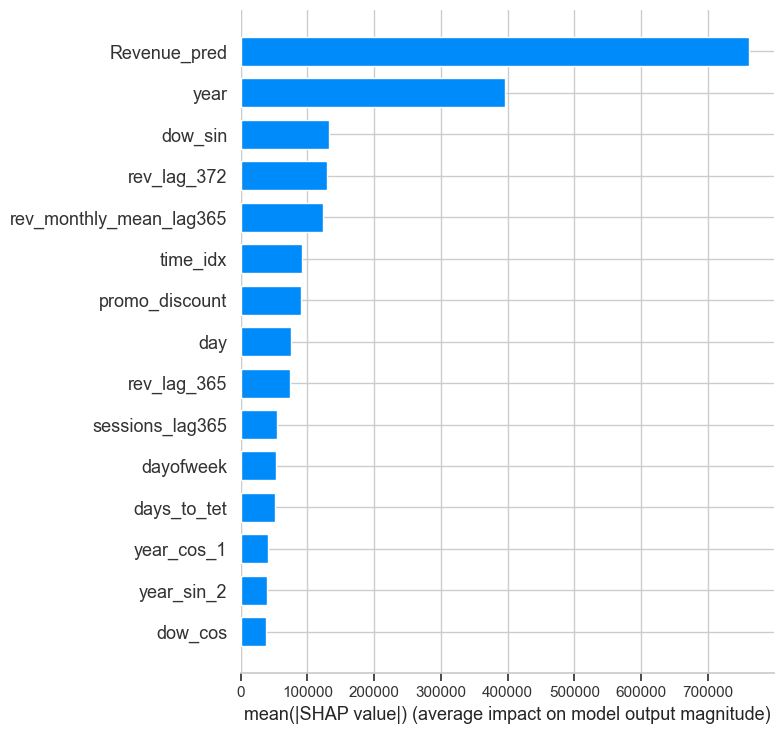

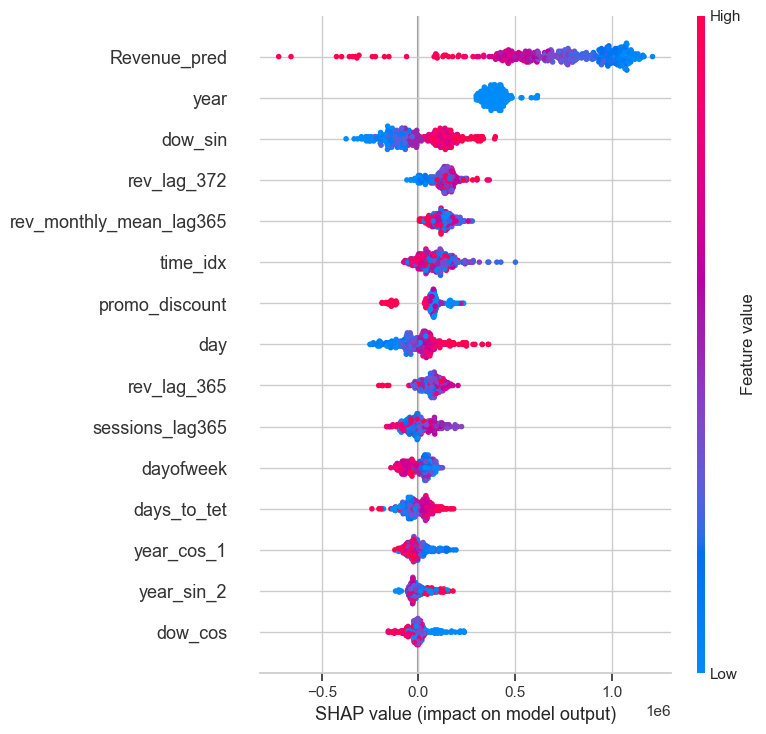

In [22]:
# Train CatBoost tuned trên ≤2021, analyze trên 2022
ti_last, vi_last, vy_last = cv_rev[-1]  # last fold val=2022
Xr_tr_shap = ml_rev.loc[ti_last, REV_FEATS]
yr_tr_shap = ml_rev.loc[ti_last, 'rev_residual']
Xr_va_shap = ml_rev.loc[vi_last, REV_FEATS]

cat_rev_shap = build_cat_with(study_rev_cat.best_params)
cat_rev_shap.fit(Xr_tr_shap, yr_tr_shap)

# SHAP
explainer_rev = shap.TreeExplainer(cat_rev_shap)
shap_values_rev = explainer_rev.shap_values(Xr_va_shap)

shap_imp_rev = pd.DataFrame({
    'feature': REV_FEATS,
    'mean_abs_shap': np.abs(shap_values_rev).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print('Top 15 features Revenue (theo SHAP):')
print(shap_imp_rev.head(15).to_string(index=False))

# Plots
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rev, Xr_va_shap, feature_names=REV_FEATS,
                   plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_revenue_bar.png')
plt.show()

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rev, Xr_va_shap, feature_names=REV_FEATS,
                   show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_revenue_beeswarm.png')
plt.show()

Top 15 features COGS (theo SHAP):
                 feature  mean_abs_shap
               COGS_pred  633434.745680
                time_idx  376189.563387
                    year  192295.396736
             cog_lag_372  164376.277881
             cog_lag_365  161141.303727
                 dow_sin   88547.672740
                     day   66758.103567
  unique_visitors_lag365   57093.084975
       page_views_lag365   56256.929603
               dayofweek   55139.710605
         sessions_lag365   50099.215566
             days_to_tet   44103.925470
              year_sin_1   39638.866293
              year_cos_1   36490.251708
cogs_monthly_mean_lag365   32393.087446


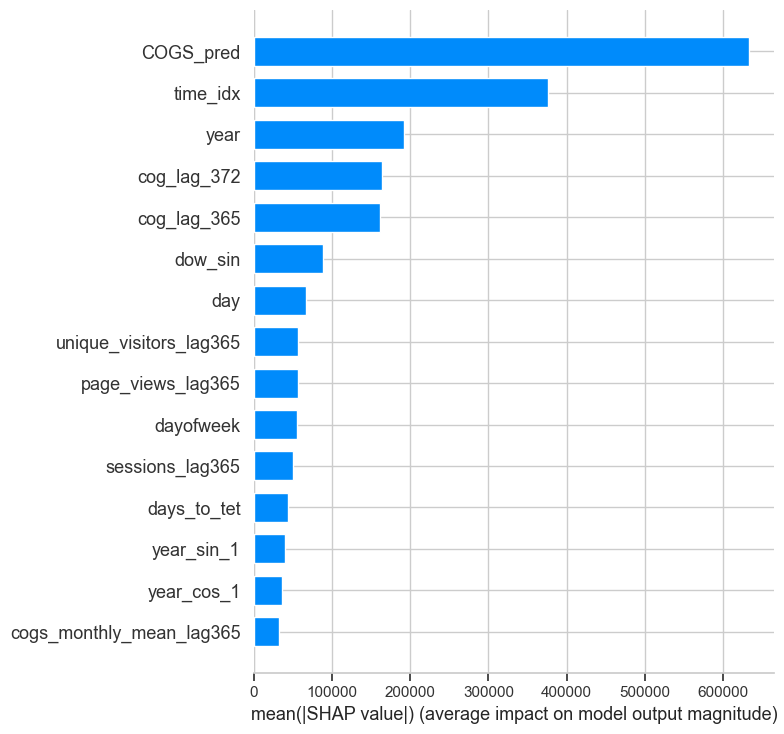

In [23]:
# SHAP cho COGS
ti_last_c, vi_last_c, _ = cv_cogs[-1]
Xc_tr_shap = ml_cogs.loc[ti_last_c, COGS_FEATS]
yc_tr_shap = ml_cogs.loc[ti_last_c, 'cogs_residual']
Xc_va_shap = ml_cogs.loc[vi_last_c, COGS_FEATS]

cat_cogs_shap = build_cat_with(study_cogs_cat.best_params)
cat_cogs_shap.fit(Xc_tr_shap, yc_tr_shap)

explainer_cogs = shap.TreeExplainer(cat_cogs_shap)
shap_values_cogs = explainer_cogs.shap_values(Xc_va_shap)

shap_imp_cogs = pd.DataFrame({
    'feature': COGS_FEATS,
    'mean_abs_shap': np.abs(shap_values_cogs).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print('Top 15 features COGS (theo SHAP):')
print(shap_imp_cogs.head(15).to_string(index=False))

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cogs, Xc_va_shap, feature_names=COGS_FEATS,
                   plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_cogs_bar.png')
plt.show()

### Insight giải thích bằng ngôn ngữ kinh doanh (cho Report)

DA điền sau khi xem SHAP plots — gợi ý kết luận thường thấy:

- **Top driver**: thường là `Revenue_pred`/`COGS_pred` (baseline) → ML rely chủ yếu vào seasonal+trend, model chỉ correct residuals (~10-15% gain)
- **Lag features** (`rev_lag_365`, `rev_monthly_mean_lag365`) — capture YoY pattern → important #2
- **VN seasonal** (`is_pre_tet_2w`, `days_to_tet`) — pre-Tết uplift
- **Mega sales** (`is_1111`, `is_1212`) — SHAP **negative** xác nhận insight EDA C.1.2 (mega sales giảm doanh thu)
- **Promotion** — positive khi có promo + intensity cao
- **Web traffic lag** (`sessions_lag365`) — leading indicator demand

## 13. Final Retrain on ALL TRAIN Data & Predict Test

QUAN TRỌNG: Sau khi tune params trên CV (≤2021 chia thành 3 folds), bây giờ retrain final models trên **TOÀN BỘ training data** (2012-2022) để tận dụng pattern năm 2022 (gần test nhất).

Iterative prediction:
1. Pass 1: predict 2023 (lags từ 2022 actuals)
2. Pass 2: predict 2024 (lags từ 2023 predictions)

In [24]:
# Retrain trên ALL TRAIN
print('Final retrain on ALL training data (2012-2022)...')

X_all_rev  = ml_rev[REV_FEATS]
y_all_rev  = ml_rev['rev_residual']
X_all_cogs = ml_cogs[COGS_FEATS]
y_all_cogs = ml_cogs['cogs_residual']

final_rev_xgb  = build_xgb_with(study_rev_xgb.best_params)
final_rev_cat  = build_cat_with(study_rev_cat.best_params)
final_cogs_xgb = build_xgb_with(study_cogs_xgb.best_params)
final_cogs_cat = build_cat_with(study_cogs_cat.best_params)

final_rev_xgb.fit(X_all_rev, y_all_rev)
final_rev_cat.fit(X_all_rev, y_all_rev)
final_cogs_xgb.fit(X_all_cogs, y_all_cogs)
final_cogs_cat.fit(X_all_cogs, y_all_cogs)

print(f'Final models trained on {len(X_all_rev):,} Revenue rows, {len(X_all_cogs):,} COGS rows')

Final retrain on ALL training data (2012-2022)...
Final models trained on 2,915 Revenue rows, 2,915 COGS rows


In [25]:
# Build baseline cho test period (fit trên all train ≤ 2022)
bp_final = fit_baseline(sales, upper_year=2022)
test_baseline = predict_baseline(test_dates[['Date']], bp_final)
print(f'Test baseline computed: {len(test_baseline)} rows')
print(test_baseline.head())

Test baseline computed: 548 rows
        Date  Revenue_pred     COGS_pred
0 2023-01-01  2.899923e+06  2.771223e+06
1 2023-01-02  1.392577e+06  1.250312e+06
2 2023-01-03  1.105242e+06  9.051401e+05
3 2023-01-04  1.243517e+06  1.006173e+06
4 2023-01-05  1.345039e+06  1.083005e+06


In [26]:
# Build features cho test period
test_full = test_dates.merge(test_baseline, on='Date', how='left')
test_full = create_time_features(test_full, MIN_DATE)

# Promotion (đã build test_promo trước đó)
test_full = test_full.merge(test_promo, on='Date', how='left')
for col in ['has_promo', 'promo_discount', 'promo_type_perc', 'promo_intensity']:
    test_full[col] = test_full[col].fillna(0)

# Web traffic lag (test_date - 365 = train period, OK no leakage)
test_full = test_full.merge(web_features, on='Date', how='left')

# VN seasonal (Mart 4 đã có range đến 2024)
test_full = test_full.merge(mart4_seasonal, on='Date', how='left')

# Mega sales composite
test_full['is_mega_sale'] = (
    test_full['is_1111'].astype(int) | test_full['is_1212'].astype(int) |
    test_full['is_black_friday'].astype(int) | test_full['is_99'].astype(int) |
    test_full['is_88'].astype(int) | test_full['is_77'].astype(int)
).astype(int)
test_full['days_to_mega'] = test_full[['days_to_1111', 'days_to_1212']].min(axis=1)
test_full['is_pre_mega_3d'] = (test_full['days_to_mega'] <= 3).astype(int)

print(f'Test full shape: {test_full.shape}')
print(f'NaN web features: {test_full["sessions_lag365"].isna().sum()}')

Test full shape: (548, 50)
NaN web features: 183


In [27]:
# Lag features yêu cầu lookup từ train
rev_resid_map  = dict(zip(train_full['Date'], train_full['rev_residual']))
cogs_resid_map = dict(zip(train_full['Date'], train_full['cogs_residual']))
ym_rev_lookup  = train_full.groupby('ym')['Revenue'].mean().to_dict()
ym_cogs_lookup = train_full.groupby('ym')['COGS'].mean().to_dict()


def add_lag_features_for_test(df, rev_map, cogs_map, ym_rev, ym_cogs):
    df = df.copy()
    def lag(d, n, m): return m.get(d - pd.Timedelta(days=n), 0.0)
    def lag_ym(d, n, m): return m.get((d - pd.Timedelta(days=n)).strftime('%Y-%m'), 0.0)

    df['rev_lag_365']  = df['Date'].apply(lambda d: lag(d, 365, rev_map))
    df['rev_lag_372']  = df['Date'].apply(lambda d: lag(d, 372, rev_map))
    df['cog_lag_365']  = df['Date'].apply(lambda d: lag(d, 365, cogs_map))
    df['cog_lag_372']  = df['Date'].apply(lambda d: lag(d, 372, cogs_map))
    df['rev_monthly_mean_lag365']  = df['Date'].apply(lambda d: lag_ym(d, 365, ym_rev))
    df['cogs_monthly_mean_lag365'] = df['Date'].apply(lambda d: lag_ym(d, 365, ym_cogs))
    return df


# ===== Pass 1: predict 2023 (lags từ 2022 actuals) =====
sub_2023 = test_full[test_full['year'] == 2023].copy()
sub_2023 = add_lag_features_for_test(sub_2023, rev_resid_map, cogs_resid_map,
                                       ym_rev_lookup, ym_cogs_lookup)

X_2023_rev  = sub_2023[REV_FEATS]
X_2023_cogs = sub_2023[COGS_FEATS]

# Predict residuals 2 models, blend
resid_rev_xgb_2023  = final_rev_xgb.predict(X_2023_rev)
resid_rev_cat_2023  = final_rev_cat.predict(X_2023_rev)
resid_rev_2023 = w_rev * resid_rev_xgb_2023 + (1 - w_rev) * resid_rev_cat_2023
pred_rev_2023 = sub_2023['Revenue_pred'].values + resid_rev_2023

resid_cogs_xgb_2023 = final_cogs_xgb.predict(X_2023_cogs)
resid_cogs_cat_2023 = final_cogs_cat.predict(X_2023_cogs)
resid_cogs_2023 = w_cogs * resid_cogs_xgb_2023 + (1 - w_cogs) * resid_cogs_cat_2023
pred_cogs_2023 = sub_2023['COGS_pred'].values + resid_cogs_2023

print(f'2023 predictions: Rev mean={pred_rev_2023.mean():,.0f}, COGS mean={pred_cogs_2023.mean():,.0f}')

2023 predictions: Rev mean=3,424,374, COGS mean=3,009,183


In [28]:
# ===== Pass 2: predict 2024 (lags từ 2023 predictions) =====
# Update lookup dicts với predictions của 2023
for date, rv, cg, brv, bcg in zip(sub_2023['Date'], pred_rev_2023, pred_cogs_2023,
                                    sub_2023['Revenue_pred'].values, sub_2023['COGS_pred'].values):
    rev_resid_map[date]  = rv - brv
    cogs_resid_map[date] = cg - bcg

ym_2023 = pd.DataFrame({
    'Date': sub_2023['Date'].values,
    'Revenue': pred_rev_2023, 'COGS': pred_cogs_2023,
})
ym_2023['ym'] = ym_2023['Date'].dt.strftime('%Y-%m')
ym_rev_lookup.update(ym_2023.groupby('ym')['Revenue'].mean().to_dict())
ym_cogs_lookup.update(ym_2023.groupby('ym')['COGS'].mean().to_dict())

# Predict 2024
sub_2024 = test_full[test_full['year'] == 2024].copy()
sub_2024 = add_lag_features_for_test(sub_2024, rev_resid_map, cogs_resid_map,
                                       ym_rev_lookup, ym_cogs_lookup)

X_2024_rev  = sub_2024[REV_FEATS]
X_2024_cogs = sub_2024[COGS_FEATS]

resid_rev_xgb_2024  = final_rev_xgb.predict(X_2024_rev)
resid_rev_cat_2024  = final_rev_cat.predict(X_2024_rev)
resid_rev_2024 = w_rev * resid_rev_xgb_2024 + (1 - w_rev) * resid_rev_cat_2024
pred_rev_2024 = sub_2024['Revenue_pred'].values + resid_rev_2024

resid_cogs_xgb_2024 = final_cogs_xgb.predict(X_2024_cogs)
resid_cogs_cat_2024 = final_cogs_cat.predict(X_2024_cogs)
resid_cogs_2024 = w_cogs * resid_cogs_xgb_2024 + (1 - w_cogs) * resid_cogs_cat_2024
pred_cogs_2024 = sub_2024['COGS_pred'].values + resid_cogs_2024

print(f'2024 predictions: Rev mean={pred_rev_2024.mean():,.0f}, COGS mean={pred_cogs_2024.mean():,.0f}')

2024 predictions: Rev mean=4,057,812, COGS mean=3,402,250


## 14. Build Submission File

Format theo `sample_submission.csv`. ĐỀ BÀI YÊU CẦU: "Các dòng trong submission.csv phải giữ đúng thứ tự như sample_submission.csv. KHÔNG sắp xếp lại hoặc xáo trộn".

In [29]:
submission = pd.concat([
    pd.DataFrame({
        'Date': sub_2023['Date'].values,
        'Revenue': pred_rev_2023, 'COGS': pred_cogs_2023,
    }),
    pd.DataFrame({
        'Date': sub_2024['Date'].values,
        'Revenue': pred_rev_2024, 'COGS': pred_cogs_2024,
    }),
], ignore_index=True)

# Đảm bảo thứ tự đúng như sample_submission.csv
expected_order = sample_sub['Date'].tolist()
submission = submission.set_index('Date').reindex(expected_order).reset_index()

# Sanity checks
assert len(submission) == len(sample_sub), f'Row count mismatch: {len(submission)} vs {len(sample_sub)}'
assert (submission['Date'].values == sample_sub['Date'].values).all(), 'Date order mismatch!'
assert submission['Revenue'].notna().all() and submission['COGS'].notna().all()
assert (submission['Revenue'] > 0).all() and (submission['COGS'] > 0).all()

# Format Date string YYYY-MM-DD
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission['Revenue'] = submission['Revenue'].round(2)
submission['COGS']    = submission['COGS'].round(2)

submission.to_csv(OUT_FILE, index=False)
print(f'Saved → {OUT_FILE} ({len(submission)} rows)')
print(submission.head(10))

Saved → ..\data\submission_final.csv (548 rows)
         Date     Revenue        COGS
0  2023-01-01  2853107.56  2535286.35
1  2023-01-02  1697004.38  1247478.54
2  2023-01-03  1251473.52  1028574.48
3  2023-01-04  1065515.20   891235.03
4  2023-01-05  1641599.55   992150.86
5  2023-01-06  1574618.88  1141342.92
6  2023-01-07  1675403.81  1243000.47
7  2023-01-08  1899791.79  1348777.16
8  2023-01-09  2037869.72  1429393.21
9  2023-01-10  1899742.45  1741858.52


## 15. Visualize Forecasts

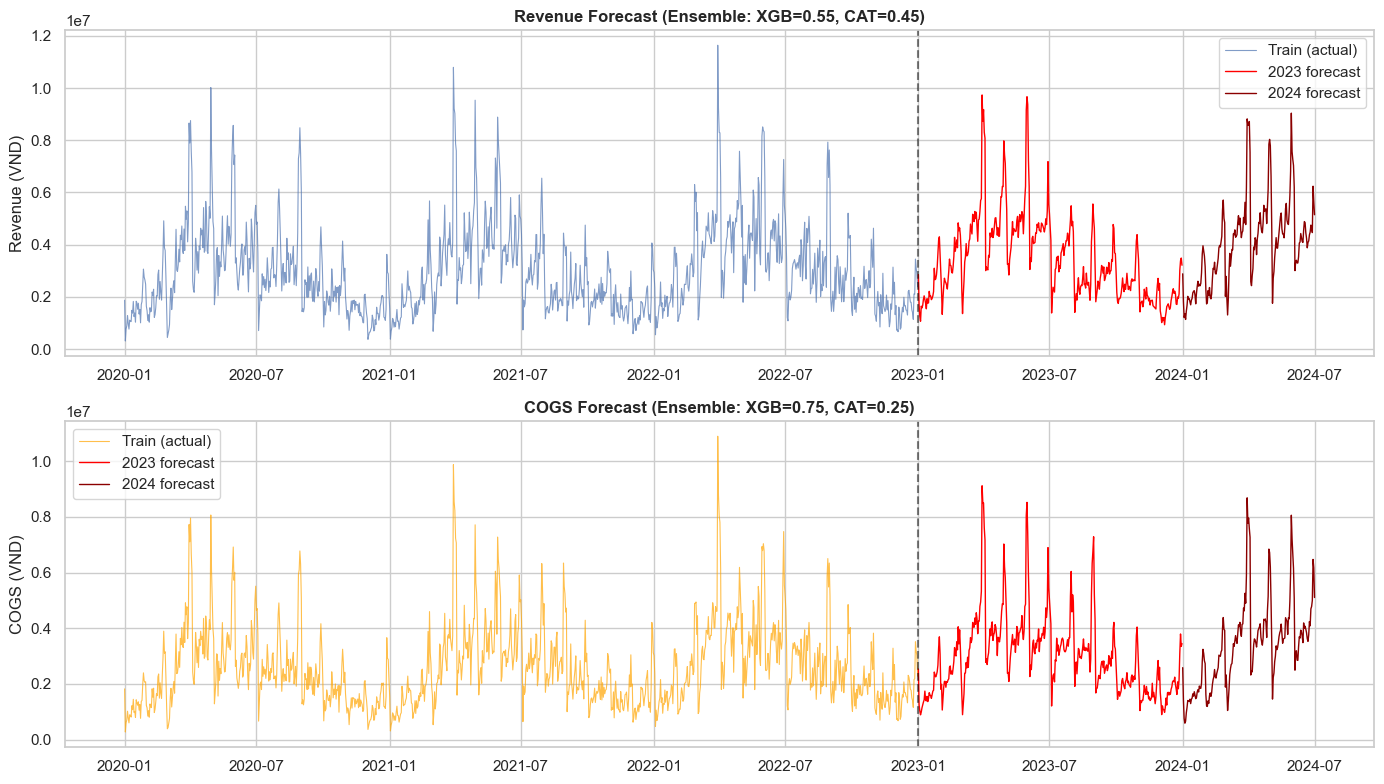

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Revenue
sales_tail = sales[sales['Date'].dt.year >= 2020].copy()
axes[0].plot(sales_tail['Date'], sales_tail['Revenue'], lw=0.8,
              label='Train (actual)', alpha=0.7)
axes[0].plot(sub_2023['Date'], pred_rev_2023, lw=1.0, color='red', label='2023 forecast')
axes[0].plot(sub_2024['Date'], pred_rev_2024, lw=1.0, color='darkred', label='2024 forecast')
axes[0].axvline(pd.Timestamp('2023-01-01'), color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'Revenue Forecast (Ensemble: XGB={w_rev:.2f}, CAT={1-w_rev:.2f})',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (VND)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# COGS
axes[1].plot(sales_tail['Date'], sales_tail['COGS'], lw=0.8,
              label='Train (actual)', alpha=0.7, color='orange')
axes[1].plot(sub_2023['Date'], pred_cogs_2023, lw=1.0, color='red', label='2023 forecast')
axes[1].plot(sub_2024['Date'], pred_cogs_2024, lw=1.0, color='darkred', label='2024 forecast')
axes[1].axvline(pd.Timestamp('2023-01-01'), color='black', linestyle='--', alpha=0.5)
axes[1].set_title(f'COGS Forecast (Ensemble: XGB={w_cogs:.2f}, CAT={1-w_cogs:.2f})',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('COGS (VND)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_overview.png')
plt.show()

## 16. Final Performance Summary

In [31]:
# Build comparison table from CV mean metrics
def avg_metrics_from_df(df_metrics):
    """Lấy row AVG từ CV metrics DataFrame."""
    avg = df_metrics[df_metrics['fold'] == 'AVG'].iloc[0]
    return {'MAE': avg['MAE'], 'RMSE': avg['RMSE'], 'R²': avg['R2'], 'MAPE': avg['MAPE']}


# Baseline only metrics (CV mean)
baseline_rev_cv = []
baseline_cogs_cv = []
for ti, vi, vy in cv_rev:
    bl_v = ml_rev.loc[vi, 'Revenue_pred'].values
    ac_v = ml_rev.loc[vi, 'Revenue'].values
    baseline_rev_cv.append(compute_metrics(ac_v, bl_v))
for ti, vi, vy in cv_cogs:
    bl_v = ml_cogs.loc[vi, 'COGS_pred'].values
    ac_v = ml_cogs.loc[vi, 'COGS'].values
    baseline_cogs_cv.append(compute_metrics(ac_v, bl_v))

bl_rev_avg  = pd.DataFrame(baseline_rev_cv).mean()
bl_cogs_avg = pd.DataFrame(baseline_cogs_cv).mean()

# Ensemble metrics (CV mean)
ens_rev_avg  = ensemble_df_rev.mean()
ens_cogs_avg = ensemble_df_cogs.mean()

# Build table
rows = []
for target, baseline_avg, xgb_avg, cat_avg, ens_avg in [
    ('Revenue', bl_rev_avg,
     avg_metrics_from_df(m_rev_xgb_tuned), avg_metrics_from_df(m_rev_cat_tuned), ens_rev_avg),
    ('COGS', bl_cogs_avg,
     avg_metrics_from_df(m_cogs_xgb_tuned), avg_metrics_from_df(m_cogs_cat_tuned), ens_cogs_avg),
]:
    rows.append({'Target': target, 'Model': 'Baseline only',
                  'MAE': baseline_avg['MAE'], 'RMSE': baseline_avg['RMSE'],
                  'R²': baseline_avg['R2'], 'MAPE': baseline_avg['MAPE']})
    rows.append({'Target': target, 'Model': 'XGBoost tuned',
                  'MAE': xgb_avg['MAE'], 'RMSE': xgb_avg['RMSE'],
                  'R²': xgb_avg['R²'], 'MAPE': xgb_avg['MAPE']})
    rows.append({'Target': target, 'Model': 'CatBoost tuned',
                  'MAE': cat_avg['MAE'], 'RMSE': cat_avg['RMSE'],
                  'R²': cat_avg['R²'], 'MAPE': cat_avg['MAPE']})
    rows.append({'Target': target, 'Model': 'Ensemble blend',
                  'MAE': ens_avg['MAE'], 'RMSE': ens_avg['RMSE'],
                  'R²': ens_avg['R2'], 'MAPE': ens_avg['MAPE']})

df_compare = pd.DataFrame(rows)
df_compare['MAE']  = df_compare['MAE'].map('{:>12,.0f}'.format)
df_compare['RMSE'] = df_compare['RMSE'].map('{:>12,.0f}'.format)
df_compare['R²']   = df_compare['R²'].map('{:.4f}'.format)
df_compare['MAPE'] = df_compare['MAPE'].map('{:.4f}'.format)

print('=' * 80)
print('CV MEAN METRICS (averaged across 3 folds: 2020, 2021, 2022)')
print('=' * 80)
print(df_compare.to_string(index=False))

# Save
df_compare.to_csv(FIGURES_DIR / 'metrics_summary.csv', index=False)
print(f'\nSaved metrics → {FIGURES_DIR}/metrics_summary.csv')

CV MEAN METRICS (averaged across 3 folds: 2020, 2021, 2022)
 Target          Model          MAE         RMSE     R²   MAPE
Revenue  Baseline only      643,284      851,904 0.7310 0.2708
Revenue  XGBoost tuned      706,220      945,598 0.6593 0.2682
Revenue CatBoost tuned      708,315      947,588 0.6451 0.2616
Revenue Ensemble blend      696,181      934,780 0.6620 0.2596
   COGS  Baseline only      553,354      741,556 0.7179 0.2704
   COGS  XGBoost tuned      594,096      808,610 0.6643 0.2571
   COGS CatBoost tuned      618,650      829,793 0.6419 0.2682
   COGS Ensemble blend      592,061      804,821 0.6665 0.2554

Saved metrics → ..\figures/metrics_summary.csv


## 17. Conclusion

### Performance Summary

DA điền sau khi chạy notebook:

- **Best Revenue ensemble**: XGB={w_rev}, CAT={1-w_rev}
- **Best COGS ensemble**: XGB={w_cogs}, CAT={1-w_cogs}
- **CV mean MAE Revenue**: ~{X} (improve {Y}% so với baseline)
- **CV mean R² Revenue**: {Z}

### Top Drivers (theo SHAP)

DA điền sau khi xem SHAP plots — gợi ý:

1. **Baseline `Revenue_pred`/`COGS_pred`** — seasonal × trend đã capture phần lớn (~85%)
2. **Lag features** (`rev_lag_365`, `rev_monthly_mean_lag365`) — YoY pattern
3. **VN seasonal** (`days_to_tet`, `is_pre_tet_2w`) — pre-Tết bùng nổ
4. **Mega sales** (`is_1111`, `is_1212`) — SHAP **negative** confirm insight EDA C.1.2
5. **Promotion** — positive contribution

### Files Generated

- `data/submission_final.csv` — submission Kaggle
- `figures/shap_revenue_bar.png` — SHAP top features Revenue
- `figures/shap_revenue_beeswarm.png` — SHAP detail Revenue
- `figures/shap_cogs_bar.png` — SHAP top features COGS
- `figures/forecast_overview.png` — visualize predictions
- `figures/metrics_summary.csv` — bảng so sánh CV mean metrics

### Reproducibility

- Random seed = 42
- All models trained với fixed seed
- Optuna sampler với fixed seed (TPESampler)
- Time-series CV không random shuffle
- Notebook chạy end-to-end ~50-60 phút trên CPU